# 37 — Aggregate the Internal Models Capital Charge

Combine unconstrained portfolio ES with constrained risk-class ES.

IMCC means Internal Models Capital Charge. Unconstrained ES recognises empirical dependence across classes. Constrained ES holds other classes constant and limits cross-class diversification.

This step uses: Scaled ES for the all-risk portfolio and the five broad regulatory risk classes.

It produces: The unconstrained component, constrained sum and final IMCC.

> Basel norm applied: MAR33.13–MAR33.15 apply equal 50% weights to unconstrained and constrained measures.

$$IMCC=0.5\,IMCC(C)+0.5\sum_i IMCC(C_i)$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
scaled=stage('11_scaled_es_and_imcc'); unconstrained=scaled.loc[scaled.scope=='ALL','scaled_es_capital_inr'].iloc[0]; constrained=scaled.loc[scaled.scope!='ALL','scaled_es_capital_inr'].sum(); imcc=0.5*unconstrained+0.5*constrained
display(crore_table(scaled[['scope','scaled_es_capital_inr']],['scaled_es_capital_inr']))
print(f"IMCC = 50% × {money(unconstrained)} + 50% × {money(constrained)} = {money(imcc)}")

,scope,Scaled Es Capital (INR crore)
0,ALL,25.6659
1,INTEREST_RATE,1.6849
2,CREDIT_SPREAD,1.6369
3,EQUITY,10.0083
4,FX,10.6310
5,COMMODITY,22.0921


IMCC = 50% × INR 25.67 crore + 50% × INR 46.05 crore = INR 35.86 crore


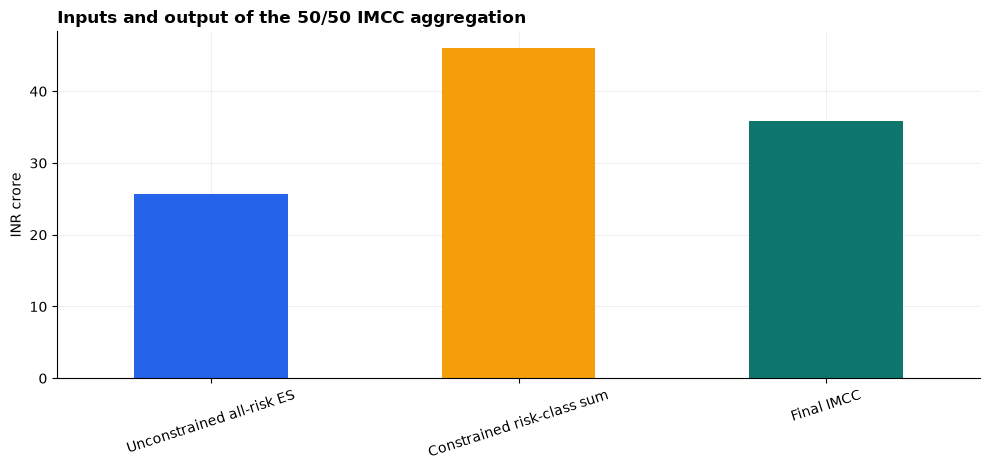

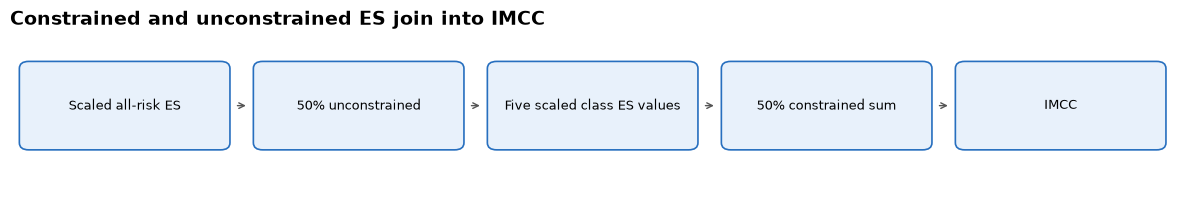

In [3]:
parts=pd.Series({'Unconstrained all-risk ES':unconstrained,'Constrained risk-class sum':constrained,'Final IMCC':imcc})/INR_CRORE; ax=parts.plot(kind='bar',color=['#2563EB','#F59E0B','#0F766E']); ax.set_ylabel('INR crore'); ax.set_title('Inputs and output of the 50/50 IMCC aggregation',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=18); plt.tight_layout(); plt.show()
draw_flow(['Scaled all-risk ES','50% unconstrained','Five scaled class ES values','50% constrained sum','IMCC'],'Constrained and unconstrained ES join into IMCC',wrap_after=5)

The bars show the two inputs to the 50/50 IMCC formula and its output. The constrained risk-class sum is larger because it restricts diversification between broad risk classes. The flow diagram makes the weighting explicit: half of the all-risk result and half of the constrained class sum form final IMCC.